In [1]:
import numpy as np
import cv2 as cv

import matplotlib.pyplot as plt

import rembg

import os

from os.path import dirname, join, abspath

### Mejor corte final

In [ ]:
BASE_DIR = 'Samples'
SRC_SUBDIR = join('04_Samples', '00_state')
TARGET_SUBDIR = join('04_Samples', '01_state')
TARGET_DIR = join(BASE_DIR, TARGET_SUBDIR)

img_paths = [
    join(BASE_DIR, SRC_SUBDIR, f'{i:02d}_model.jpeg')
    for i in range(1, 12)
]

# Depuracion: Esto es pa ver si existen las imágenes
img_paths = [p for p in img_paths if os.path.exists(p)]
if len(img_paths) == 0:
    print('No se encontraron imágenes en las rutas configuradas')

# Parámetro gamma no lo toqueis porque hasta ahora es el mejor
gamma = 2.0

def rembg_remove_np(img):

    ok, buf = cv.imencode('.png', img) # codifica a PNG. ok dice si ha ido bien y buf es un array bytes

    if not ok:
        raise RuntimeError('Error al codificar la imagen a PNG')
    
    out_bytes = rembg.remove(buf.tobytes()) # .tobytes() convierte a bytes
    out_arr = np.frombuffer(out_bytes, dtype=np.uint8) #  combierte bytes a array
    out_img = cv.imdecode(out_arr, cv.IMREAD_UNCHANGED)  # pasa de array a imagen de openCV
    return out_img

def apply_gamma(img, gamma_val):
    # Aplica corrección gamma y devuelve imagen uint8
    img_f = img.astype(np.float32) / 255.0
    out = np.clip(255.0 * np.power(img_f, gamma_val), 0, 255).astype(np.uint8)
    return out

os.makedirs(TARGET_DIR, exist_ok=True) # crea el directorio de salida si no existe


for src_path in img_paths:
    filename = os.path.basename(src_path)
    name_noext = os.path.splitext(filename)[0]
    print(f'Procesando {filename}...')

    # leer original
    img = cv.imread(src_path)
    if img is None:
        print(f'  Error leyendo {src_path}, pasamos al siguiente.')
        continue

    # aplicar corrección gamma
    img_exp = apply_gamma(img, gamma)

    # aplicar rembg sobre la imagen exp
    try:
        out = rembg_remove_np(img_exp)
    except Exception as e:
        print(f'  Error rembg sobre {filename}: {e}')
        out = None

    # Guardamos el resultado
    out_name = f'{name_noext}.png'
    out_path = join(TARGET_DIR, out_name)

    if out is None:
        print(f'  No se generó salida para {filename}, deberías repetir el proceso.')
        # Guardar la imagen exp original como fallback (sin alpha)
        cv.imwrite(out_path, img_exp)
    else:
        # Si rembg devuelve una imagen con 4 canales (BGRA) o 3 canales
        # cv.imwrite maneja ambos casos
        written = cv.imwrite(out_path, out)
        if not written:
            print(f'  Error escribiendo {out_path}, deberías repetir el proceso.')
            cv.imwrite(out_path, img_exp)

    print(f'  Guardado -> {out_path}')

print('Procesamiento completado.')


Procesando 01_model.jpeg...
  Guardado -> Samples\04_Samples\01_state\01_model.png
Procesando 02_model.jpeg...
  Guardado -> Samples\04_Samples\01_state\02_model.png
Procesando 03_model.jpeg...
  Guardado -> Samples\04_Samples\01_state\03_model.png
Procesando 04_model.jpeg...
  Guardado -> Samples\04_Samples\01_state\04_model.png
Procesando 05_model.jpeg...
  Guardado -> Samples\04_Samples\01_state\05_model.png
Procesando 06_model.jpeg...
  Guardado -> Samples\04_Samples\01_state\06_model.png
Procesando 07_model.jpeg...
  Guardado -> Samples\04_Samples\01_state\07_model.png
Procesando 08_model.jpeg...
  Guardado -> Samples\04_Samples\01_state\08_model.png
Procesando 09_model.jpeg...
  Guardado -> Samples\04_Samples\01_state\09_model.png
Procesando 10_model.jpeg...
  Guardado -> Samples\04_Samples\01_state\10_model.png
Procesando 11_model.jpeg...
  Guardado -> Samples\04_Samples\01_state\11_model.png
Procesamiento completado.


### Puntos y maching

Caso 0,1
Puntos encontrados img1: 73
Puntos encontrados img2: 121
Buenos emparejamientos (Matches): 8
Caso 1,2
Puntos encontrados img1: 121
Puntos encontrados img2: 164
Buenos emparejamientos (Matches): 21
Caso 2,3
Puntos encontrados img1: 164
Puntos encontrados img2: 83
Buenos emparejamientos (Matches): 31
Caso 3,4
Puntos encontrados img1: 83
Puntos encontrados img2: 115
Buenos emparejamientos (Matches): 5
Caso 4,5
Puntos encontrados img1: 115
Puntos encontrados img2: 44
Buenos emparejamientos (Matches): 13
Caso 5,6
Puntos encontrados img1: 44
Puntos encontrados img2: 62
Buenos emparejamientos (Matches): 7
Caso 6,7
Puntos encontrados img1: 62
Puntos encontrados img2: 51
Buenos emparejamientos (Matches): 3
Caso 7,8
Puntos encontrados img1: 51
Puntos encontrados img2: 60
Buenos emparejamientos (Matches): 5
Caso 8,9
Puntos encontrados img1: 60
Puntos encontrados img2: 88
Buenos emparejamientos (Matches): 4
Caso 9,10
Puntos encontrados img1: 88
Puntos encontrados img2: 93
Buenos emparejam

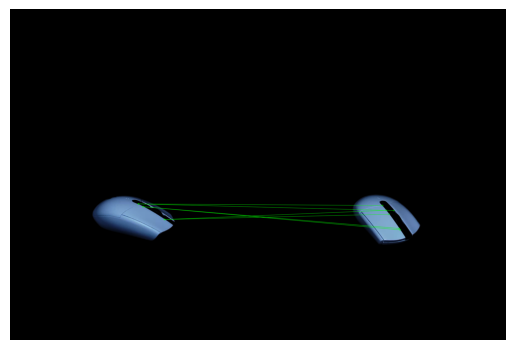

In [ ]:
def feature_and_matching_test(im1, im2):
  #Buscamos los puntos característicos con sus descriptores con el SIFT
  sift = cv.SIFT_create()
  kp1, des1 = sift.detectAndCompute(im1, None)
  kp2, des2 = sift.detectAndCompute(im2, None)
  #Buscamos una asicoación entre los puntos de las dos imágenes, usaremos el de fuerza bruta BFMatcher
  bf = cv.BFMatcher()

  matches = bf.knnMatch(des1, des2, k=2)
  #Escogemos sólo las asociaciones de puntos cercanos
  good_matches = []
  for m, n in matches:
    if m.distance <  n.distance*0.7:
      good_matches.append((m,n)) 

  #Medimos rendimiento
  img_matched = cv.drawMatchesKnn(im1, kp1, im2, kp2, good_matches, None, matchColor=(0, 255, 0),
                       singlePointColor=(0, 255, 0), flags=2)
  plt.imshow(img_matched)
  plt.axis('off')
  print(f"Puntos encontrados img1: {len(kp1)}")
  print(f"Puntos encontrados img2: {len(kp2)}")
  print(f"Buenos emparejamientos (Matches): {len(good_matches)}")

BASE_DIR = 'Samples'
SRC_SUBDIR = join('04_Samples', '01_state')

img_paths = [
    join(BASE_DIR, SRC_SUBDIR, f'{i:02d}_model.png')
    for i in range(1, 12)
]

imgs_clean = []

for src_path in img_paths:
  img = cv.imread(src_path)
  if img is None:
    print(f"No se pudo cargar la imagen {src_path}")
    continue
  imgs_clean.append(img)

for i,j in zip(range(10),range(1,11)):
  print(f'Caso {i},{j}')
  feature_and_matching_test(imgs_clean[i], imgs_clean[j])